# Explore MuData File

This notebook demonstrates how to load, inspect, and visualize a MuData (`.h5mu`) file produced by `mosa convert`.

**Setup:** Change `DATA_PATH` in the cell below to point to your `.h5mu` file, then run all cells.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import mudata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

# Change this to your .h5mu file path
DATA_PATH = "/Users/cmac/Documents/Faculdade/thesis/repositories/mosa/data/dataset.h5mu"

## 1. Load & Overview

In [5]:
# Load the MuData object
mdata = mudata.read(DATA_PATH)

print("===== MuData Summary =====")
print(f"Total samples: {mdata.n_obs}")
print(f"Modalities: {list(mdata.mod.keys())}")
print(f"\nMuData object:")
print(mdata)

===== MuData Summary =====
Total samples: 4905
Modalities: ['gexp_voom', 'meth_combat']

MuData object:
MuData object with n_obs × n_vars = 4905 × 30105
  obs:	'model_type', 'tissue', 'project'
  2 modalities
    gexp_voom:	4905 x 15905
      layers:	'mask'
    meth_combat:	4905 x 14200
      layers:	'mask'


## 2. Inspect Samplesheet (`.obs`)

In [6]:
# Display .obs (metadata) — drop unnamed index-artifact columns if present
obs = mdata.obs.loc[:, ~mdata.obs.columns.str.match(r"^Unnamed")]

print("===== Samplesheet (.obs) =====")
print(f"Shape: {obs.shape}")
print(f"\nColumns: {list(obs.columns)}")
print(f"\nFirst 5 rows:")
print(obs.head())

print(f"\n===== Categorical Summaries =====")
for col in ["model_type", "tissue"]:
    if col in obs.columns:
        print(f"\n{col}:")
        print(obs[col].value_counts())

===== Samplesheet (.obs) =====
Shape: (4905, 3)

Columns: ['model_type', 'tissue', 'project']

First 5 rows:
          model_type                       tissue                      project
SIDM00001  Cell Line  Haematopoietic and Lymphoid  Haematopoietic and Lymphoid
SIDM00002  Cell Line    Peripheral Nervous System    Peripheral Nervous System
SIDM00003  Cell Line                         Skin                         Skin
SIDM00005  Cell Line                       Breast                       Breast
SIDM00006  Cell Line                         Skin                         Skin

===== Categorical Summaries =====

model_type:
model_type
Tumor        3474
Cell Line    1293
Organoid      138
Name: count, dtype: int64

tissue:
tissue
Lung                           1255
Central Nervous System          875
Large Intestine                 763
Skin                            549
Haematopoietic and Lymphoid     427
Esophagus                       270
Pancreas                        240
Breast    

## 3. Inspect Each Modality

In [7]:
# For each modality, show shape, feature names, and mask coverage
for name, adata in mdata.mod.items():
    print(f"\n===== Modality: {name} =====")
    print(f"Shape: {adata.shape} (samples x features)")
    print(f"Feature names (first 10): {list(adata.var_names[:10])}")

    X = adata.X
    if issparse(X):
        X = X.toarray()

    nan_pct = np.isnan(X).sum() / X.size * 100
    print(f"\nNaN fraction: {nan_pct:.1f}%")
    print(f"Data range: [{np.nanmin(X):.4f}, {np.nanmax(X):.4f}]")
    print(f"Mean: {np.nanmean(X):.4f}, Std: {np.nanstd(X):.4f}")

    if "mask" in adata.layers:
        mask = adata.layers["mask"]
        if issparse(mask):
            mask = mask.toarray()
        mask_coverage = (mask.sum() / mask.size) * 100
        print(f"Mask coverage: {mask_coverage:.1f}% (non-missing values)")


===== Modality: gexp_voom =====
Shape: (4905, 15905) (samples x features)
Feature names (first 10): ['A1CF', 'A2M', 'A2ML1', 'A4GALT', 'AAAS', 'AACS', 'AADAC', 'AADAT', 'PRXL2C', 'AAGAB']

NaN fraction: 0.0%
Data range: [-10.1272, 20.4927]
Mean: 3.2463, Std: 3.7025
Mask coverage: 100.0% (non-missing values)

===== Modality: meth_combat =====
Shape: (4905, 14200) (samples x features)
Feature names (first 10): ['A1BG', 'A2BP1', 'A2LD1', 'A4GALT', 'AAAS', 'AACS', 'AADAT', 'AAGAB', 'AAK1', 'AAMP']

NaN fraction: 23.8%
Data range: [-11.0566, 13.6414]
Mean: -1.6914, Std: 1.8894
Mask coverage: 76.2% (non-missing values)


## 4. Feature Value Distributions

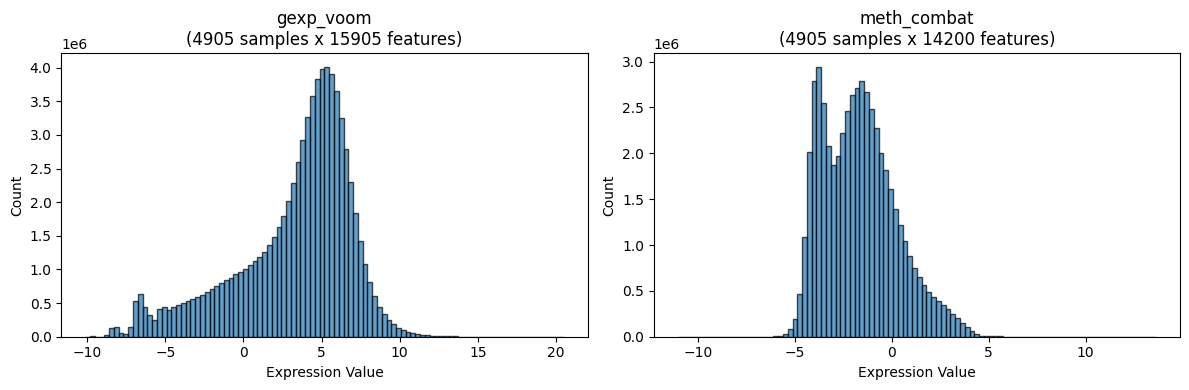

In [8]:
# Plot distributions of feature values per modality
fig, axes = plt.subplots(1, len(mdata.mod), figsize=(12, 4))
if len(mdata.mod) == 1:
    axes = [axes]

for ax, (name, adata) in zip(axes, mdata.mod.items()):
    X = adata.X
    if issparse(X):
        X = X.toarray()
    
    # Flatten and plot histogram
    ax.hist(X.flatten(), bins=100, alpha=0.7, edgecolor='black')
    ax.set_title(f"{name}\n({X.shape[0]} samples x {X.shape[1]} features)")
    ax.set_xlabel("Expression Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5. UMAP Visualization per Modality

Computing UMAP for gexp_voom...


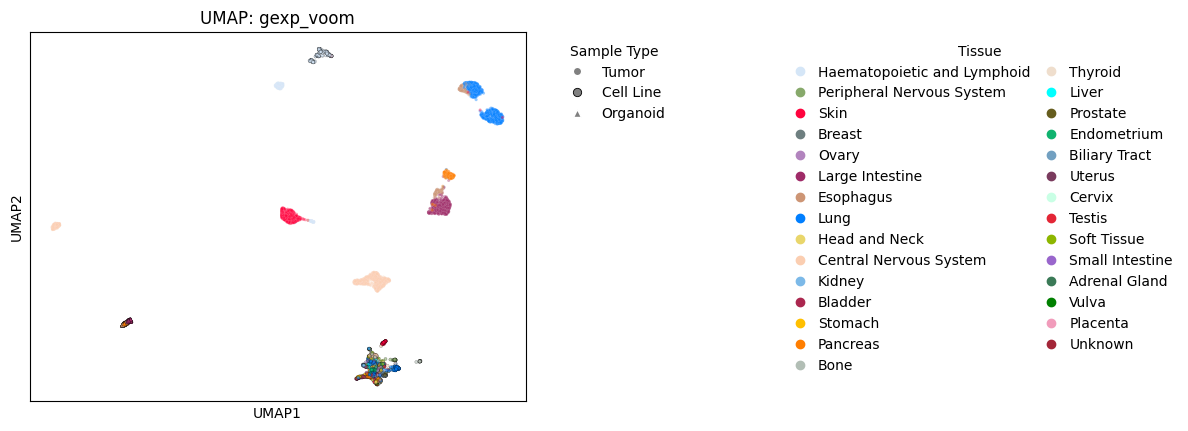

Computing UMAP for meth_combat...


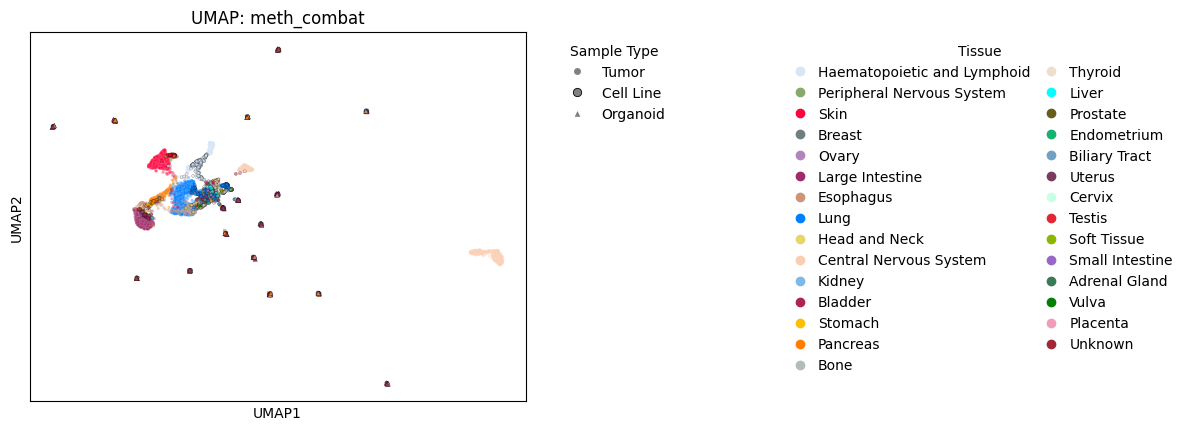

In [9]:
# umap-learn must be installed: pip install umap-learn
from mosa.plot_utils import compute_umap_embedding, plot_umap, DEFAULT_PALETTE

for name, adata in mdata.mod.items():
    print(f"Computing UMAP for {name}...")

    X = adata.X
    if issparse(X):
        X = X.toarray()

    # Impute NaN with column means before PCA/UMAP
    col_means = np.nanmean(X, axis=0)
    nan_mask = np.isnan(X)
    X_imp = X.copy()
    X_imp[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    df = pd.DataFrame(X_imp, index=adata.obs_names, columns=adata.var_names)
    embedding = compute_umap_embedding(df, pca_components=50)

    plot_df = pd.concat([
        embedding,
        mdata.obs[["tissue", "model_type"]].astype(str)
    ], axis=1)

    try:
        # plot_umap creates its own figure internally
        fig, ax = plot_umap(plot_df, DEFAULT_PALETTE, title=f"UMAP: {name}")
    except Exception as e:
        print(f"Warning: {e} — falling back to plain scatter")
        fig, ax = plt.subplots(figsize=(10, 8))
        for tissue in plot_df["tissue"].unique():
            subset = plot_df[plot_df["tissue"] == tissue]
            ax.scatter(subset["UMAP1"], subset["UMAP2"], label=tissue, alpha=0.6)
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")
        ax.set_title(f"UMAP: {name}")
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)

    plt.tight_layout()
    plt.show()

## 6. Summary Statistics per Modality and Tissue

In [10]:
# Summary: mean expression per tissue per modality (NaN-safe)
print("===== Mean Expression by Tissue =====")
for name, adata in mdata.mod.items():
    X = adata.X
    if issparse(X):
        X = X.toarray()

    df = pd.DataFrame(X, index=adata.obs_names)
    df["tissue"] = mdata.obs["tissue"].values

    print(f"\n{name}:")
    tissue_means = df.groupby("tissue").apply(
        lambda x: np.nanmean(x.iloc[:, :-1].values)
    )
    print(tissue_means)

===== Mean Expression by Tissue =====

gexp_voom:
tissue
Adrenal Gland                  2.605229
Biliary Tract                  2.915668
Bladder                        2.822728
Bone                           2.894056
Breast                         2.846731
Central Nervous System         3.489363
Cervix                         2.771500
Endometrium                    2.861104
Esophagus                      3.281906
Haematopoietic and Lymphoid    2.715315
Head and Neck                  2.967464
Kidney                         2.826293
Large Intestine                3.283614
Liver                          2.852780
Lung                           3.387606
Ovary                          2.936250
Pancreas                       3.434672
Peripheral Nervous System      2.836715
Placenta                       2.521578
Prostate                       2.894591
Skin                           3.164241
Small Intestine                2.746449
Soft Tissue                    2.818105
Stomach                